In [1]:
# ==============================================================================
# STEP 1: SETUP
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# ==============================================================================
# STEP 2: DATA LOADING
# ==============================================================================
# เปลี่ยนชื่อไฟล์ให้ตรงกับที่คุณมีนะครับ
file_2017 = 'wave-7-shocksclean.dta' 
df_17 = pd.read_stata(file_2017, convert_categoricals=False)

# ==============================================================================
# STEP 3: DATA CLEANING & COPING TRANSFORMATION (สำคัญ: ส่วนนี้ที่หายไป)
# ==============================================================================
def full_clean_wave7_2017(df):
    # 1. จัดการ Missing Values
    df = df.replace([-9, -99, -9.0, -99.0], np.nan)
    
    # 2. จัดการคอลัมน์เงิน
    money_cols = ['_x31005a', '_x31005b', '_x31006a']
    for col in money_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype(str).str.replace('none', '0'), errors='coerce').fillna(0)
    
    # คำนวณ Impact
    df['impact_3way'] = df['_x31005a'] + df['_x31005b'] + df['_x31006a']
    df['impact_2way'] = df['_x31005a'] + df['_x31006a']

    # 3. สร้างคอลัมน์ Coping (6 หมวดมาตรฐาน)
    # Mapping รหัสรับมือให้เข้ากลุ่ม
    coping_map = {
        11: 'sold_assets', 12: 'sold_assets', 13: 'sold_assets', 14: 'sold_assets',
        15: 'used_savings', 16: 'used_insurance',
        17: 'borrowed_informal', 18: 'borrowed_informal', 19: 'borrowed_informal', 20: 'borrowed_informal',
        21: 'borrowed_formal', 22: 'borrowed_formal', 23: 'borrowed_formal', 
        28: 'gov_help', 29: 'gov_help', 30: 'relatives_help'
    }
    
    target_coping = ['sold_assets', 'used_savings', 'used_insurance', 'borrowed_informal', 'borrowed_formal', 'gov_help']
    for cat in target_coping:
        df[f'coping_{cat}'] = 0
    
    # วนลูปเช็คจากลำดับที่ 1, 2, 3 (_x31008, _x31009, _x31010)
    for col in ['_x31008', '_x31009', '_x31010']:
        if col in df.columns:
            for code, cat_name in coping_map.items():
                df.loc[df[col] == code, f'coping_{cat_name}'] = 1

    # 4. Shock Grouping
    shock_mapping = {
        10: 'agricultural', 11: 'agricultural', 63: 'agricultural', 55: 'agricultural',
        1: 'demographic', 2: 'demographic', 3: 'demographic', 24: 'demographic',
        5: 'economics', 6: 'economics', 18: 'economics', 21: 'economics', 22: 'economics', 62: 'economics',
        8: 'social', 70: 'social', 77: 'economics'
    }
    df['shocks_Group'] = df['_x31002'].map(shock_mapping).fillna('others')
    df['survey_year'] = 2017
    
    return df

df_17 = full_clean_wave7_2017(df_17)
output_file = 'shocks_2017_cleaned_final.csv'
df_17.to_csv(output_file, index=False)

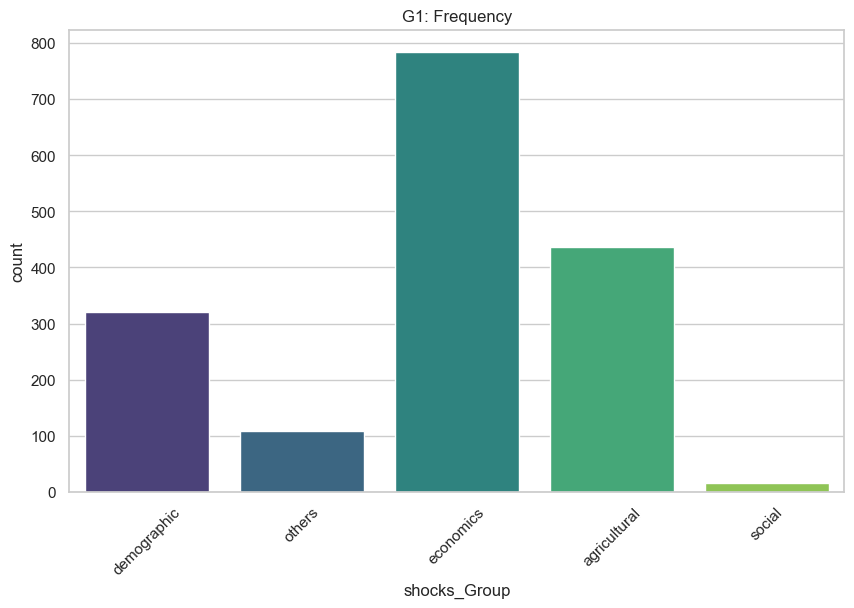

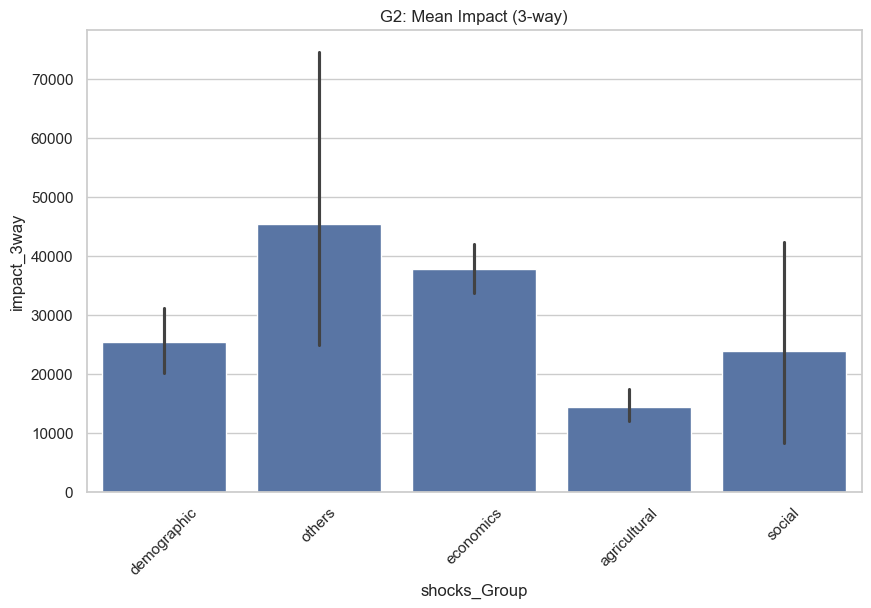

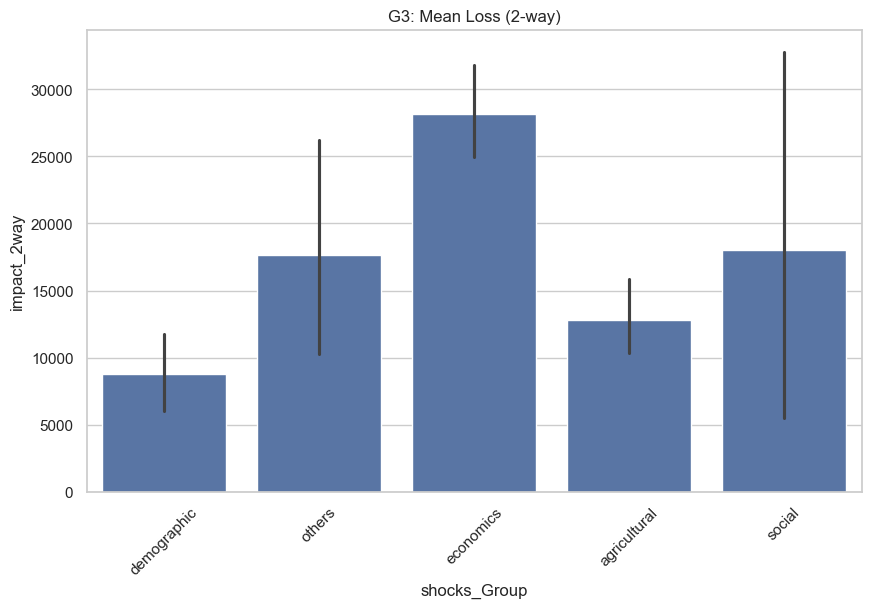

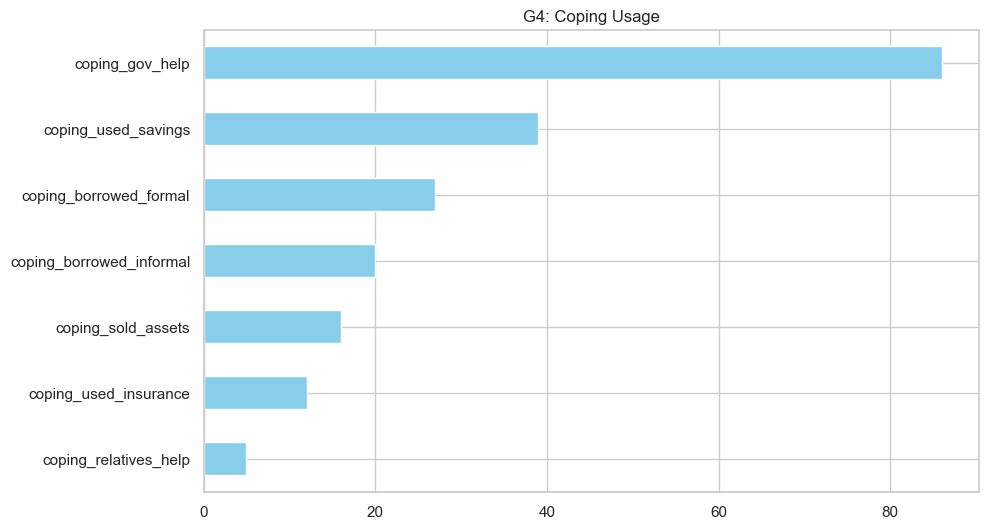

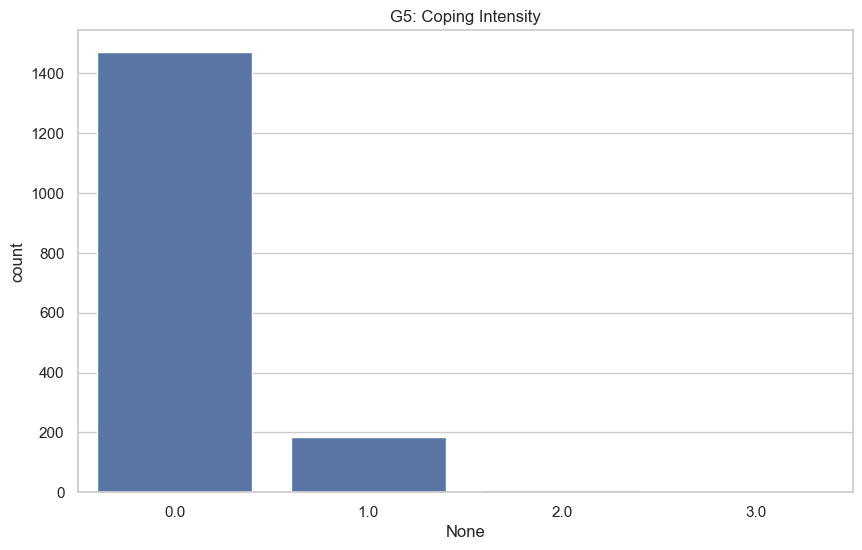

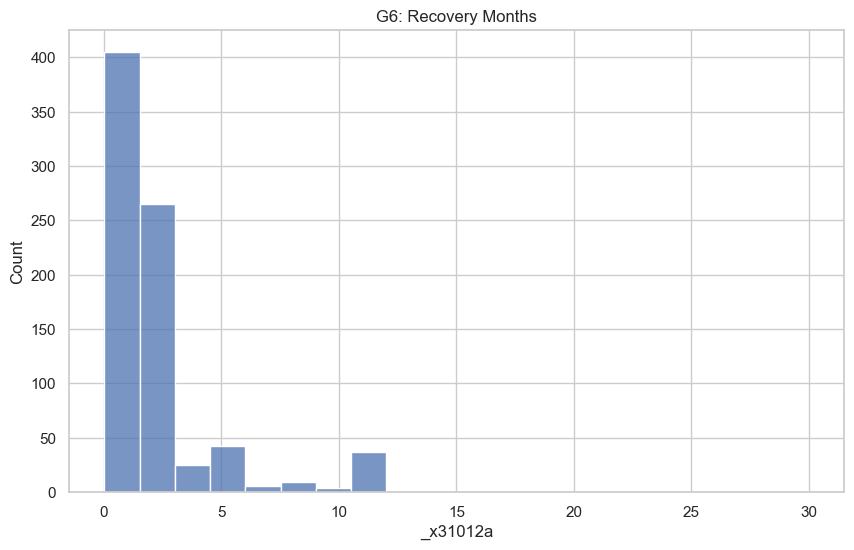

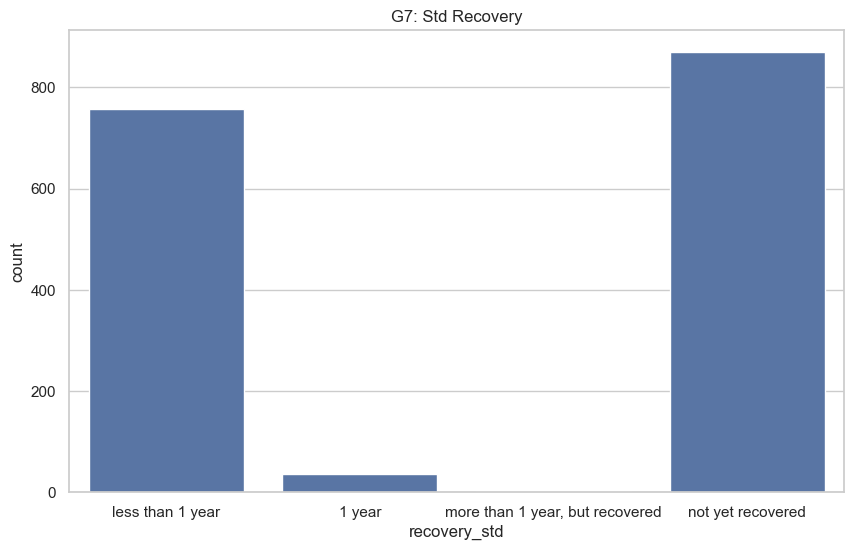

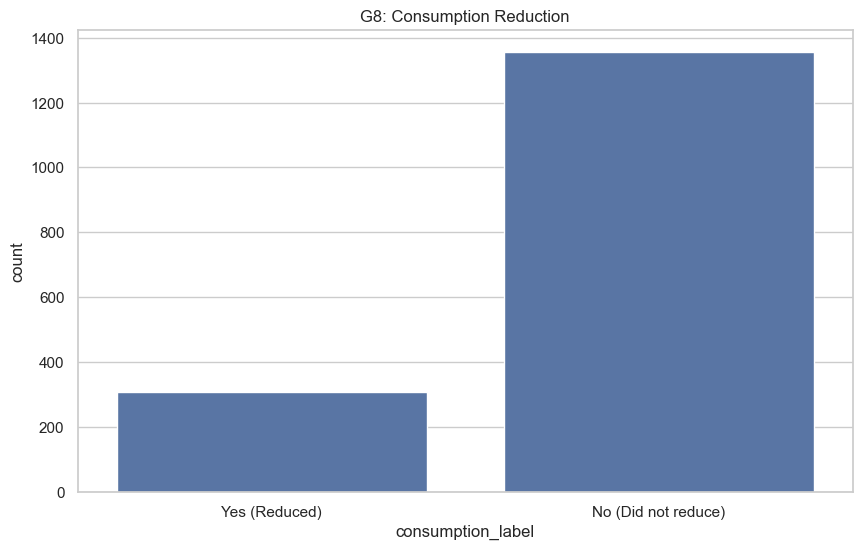

In [2]:
# ==============================================================================
# STEP 4: 8 MASTER DESCRIPTIVE GRAPHS
# ==============================================================================
def run_wave7_analysis_fixed(df, year):
    output_dir = f"graphs_wave_{year}"
    if not os.path.exists(output_dir): os.makedirs(output_dir)

    # Pre-mapping
    def map_to_wave1_recovery(m):
        if pd.isna(m): return np.nan
        if m < 12: return "less than 1 year"
        if m == 12: return "1 year"
        if 12 < m < 90: return "more than 1 year, but recovered"
        if m >= 90: return "not yet recovered"
        return np.nan

    df['recovery_std'] = df['_x31012a'].apply(map_to_wave1_recovery)
    df['consumption_label'] = df['_x31011'].map({1: "Yes (Reduced)", 2: "No (Did not reduce)"})

    # List of Graphs
    plt.figure(figsize=(10,6)); sns.countplot(data=df, x='shocks_Group', palette='viridis'); plt.title('G1: Frequency'); plt.xticks(rotation=45); plt.savefig(f'{output_dir}/G1.png'); plt.show()
    plt.figure(figsize=(10,6)); sns.barplot(data=df, x='shocks_Group', y='impact_3way', estimator=np.mean); plt.title('G2: Mean Impact (3-way)'); plt.xticks(rotation=45); plt.savefig(f'{output_dir}/G2.png'); plt.show()
    plt.figure(figsize=(10,6)); sns.barplot(data=df, x='shocks_Group', y='impact_2way', estimator=np.mean); plt.title('G3: Mean Loss (2-way)'); plt.xticks(rotation=45); plt.savefig(f'{output_dir}/G3.png'); plt.show()
    
    # กราฟที่ 4 (ที่เคยพัง): ตอนนี้ coping_vars จะไม่ว่างแล้ว
    plt.figure(figsize=(10,6)); coping_vars = [c for c in df.columns if c.startswith('coping_')]
    df[coping_vars].sum().sort_values().plot(kind='barh', color='skyblue'); plt.title('G4: Coping Usage'); plt.savefig(f'{output_dir}/G4.png'); plt.show()
    
    plt.figure(figsize=(10,6)); sns.countplot(data=df, x=df[coping_vars].sum(axis=1)); plt.title('G5: Coping Intensity'); plt.savefig(f'{output_dir}/G5.png'); plt.show()
    plt.figure(figsize=(10,6)); sns.histplot(data=df[df['_x31012a'] < 90], x='_x31012a', bins=20); plt.title('G6: Recovery Months'); plt.savefig(f'{output_dir}/G6.png'); plt.show()
    
    plt.figure(figsize=(10,6)); recovery_order = ["less than 1 year", "1 year", "more than 1 year, but recovered", "not yet recovered"]
    sns.countplot(data=df, x='recovery_std', order=recovery_order); plt.title('G7: Std Recovery'); plt.savefig(f'{output_dir}/G7.png'); plt.show()
    
    plt.figure(figsize=(10,6)); sns.countplot(data=df[df['consumption_label'].notnull()], x='consumption_label'); plt.title('G8: Consumption Reduction'); plt.savefig(f'{output_dir}/G8.png'); plt.show()

# เรียกใช้งาน
run_wave7_analysis_fixed(df_17, 2017)